<a href="https://colab.research.google.com/github/Xiaosheng-Zhao/SpecCLIP/blob/main/downstream-with-demo/colab_tutorial_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Xiaosheng-Zhao/SpecCLIP/blob/main/downstream-with-demo/colab_tutorial_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SpecCLIP — Full Colab Tutorial

Cross-survey stellar spectroscopy with [SpecCLIP](https://github.com/Xiaosheng-Zhao/SpecCLIP). This is the **full** tutorial: stellar-parameter prediction, similar-star retrieval, cross-modal prediction, and combined analysis cards — all in one self-contained Colab session.

**What you will do**
1. Set up the Colab runtime (clone repo, install deps, download models + test data)
2. Authenticate with Hugging Face
3. **Predict stellar parameters** (atmospheric, chemical, asteroseismic, extinction) from a LAMOST LRS or Gaia XP spectrum
4. **Retrieve** similar stars in-modal and cross-modal
5. **Predict** the paired spectrum in the other survey from the embedding
6. Generate **comprehensive analysis cards** combining all of the above

**Paper:** [SpecCLIP: Aligning and Translating Spectroscopic Measurements for Stars](https://arxiv.org/abs/2507.01939)

> **Tip.** Switch to a GPU runtime before you start (`Runtime → Change runtime type → T4 GPU`). CPU works but is materially slower, especially for the embedding-build step.

> **Note on storage.** Colab's `/content/` is ephemeral — everything downloaded by this notebook (~2.3 GB of model checkpoints + ~10 MB test data) disappears when the runtime is recycled. Re-running this notebook in a fresh session takes ~3 minutes to re-download.


## 0. Check the runtime


In [1]:
import torch

if torch.cuda.is_available():
    print("CUDA available:", True)
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA available: False — running on CPU (slower, but fine for this demo)")


CUDA available: True
GPU: Tesla T4


## 1. Clone the SpecCLIP repository


In [2]:
import os, subprocess

REPO_URL = "https://github.com/Xiaosheng-Zhao/SpecCLIP.git"
# Use an absolute path so this cell is idempotent — re-running won't keep
# nesting the clone inside the previous working directory.
ROOT = "/content" if os.path.isdir("/content") else os.path.abspath(".")
REPO_DIR = os.path.join(ROOT, "SpecCLIP")

if not os.path.isdir(REPO_DIR):
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
        check=True,
    )

%cd "{REPO_DIR}"
!ls


/content/SpecCLIP
config		      __init__.py  requirements.txt  specclip
downstream-with-demo  LICENSE	   scripts	     specclip.egg-info
img		      README.md    setup.py	     utils


## 2. Install dependencies

We install only what this demo actually imports.

We deliberately skip `pip install -r requirements.txt` because it pins `lightning==1.9.5` (an early-2023 release used for training). That old Lightning drags in very old `pydantic` / `starlette` / `fastapi` / `websockets`, which pip then downgrades — leaving Colab's preinstalled stack (gradio, langchain, google-genai, …) in an inconsistent state. The retrieval code only ever **loads** checkpoints, which works with any modern Lightning version.

We also skip `pip install -e .` because editable installs have been flaky in recent Colab + setuptools combinations. Instead, section 6 below adds the SpecCLIP repo root to `sys.path` so the `specclip` package imports cleanly without an install step.

`lightning` (the umbrella package, not `pytorch-lightning` — they are different distributions on PyPI) provides the `lightning.*` namespace that `specclip` imports via `import lightning as L`. Installing it transitively pulls in `pytorch-lightning` too, which gives us the legacy `pytorch_lightning` namespace used by the predict helpers.

You may see "dependency resolver" warnings from `sbi` against Colab's stack — those are non-fatal; the demo cells below do not touch the affected packages.


In [3]:
# Slim install. See the note above for why we skip requirements.txt and -e install.
# IMPORTANT: install `lightning`, NOT `pytorch-lightning` — they are different PyPI
# distributions and only the umbrella provides the `lightning.*` namespace.
!pip install huggingface_hub sbi lightning

import importlib
importlib.invalidate_caches()
for _pkg in ("lightning", "lightning.pytorch", "pytorch_lightning",
             "huggingface_hub", "sbi"):
    try:
        importlib.import_module(_pkg)
        print(f"  [OK] {_pkg} importable")
    except ImportError as e:
        print(f"  [FAIL] {_pkg}: {e}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.9/517.9 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 31.5 MB/s eta 0:00:00
  Created wheel for nflows: filename=nflows-0.14-py3-none-any.whl size=53654 sha256=4d7b6a2fde9cfee0b2b00be7046e751b4ee0a0655bb80498f7c947a5ece19c6d
  Stored in directory: /root/.cache/pip/wheels/fd/27/c3/8952205ea17b63dc1eaa24031e63111c6a3661cb22cc1e2a3c
Successfully built nflows
  [OK] lightning importable
  [OK]

## 3. Move into the demo directory

The helper scripts (`spectral_retrieval.py`, `stellar_params_unified.py`, `download_and_setup.py`, `predict_*_wclip_v0.py`) live in `downstream-with-demo/` and expect to be run from there.


In [4]:
# Absolute path -> idempotent if you re-run this cell.
%cd "{REPO_DIR}/downstream-with-demo"
!ls


/content/SpecCLIP/downstream-with-demo
colab_tutorial_full.ipynb  config_xp.json	    predict_xp_wclip_v0.py
colab_tutorial.ipynb	   demo_download_v0.ipynb   __pycache__
config.json		   download_and_setup.py    spectral_retrieval.py
config_lrs.json		   download_test_data.py    stellar_params_unified.py
config_retrieval.json	   predict_lrs_wclip_v0.py  test_data


## 4. (Optional) Authenticate with Hugging Face

The SpecCLIP checkpoints live in the **public** Hugging Face repo [`astroshawn/SpecCLIP`](https://huggingface.co/astroshawn/SpecCLIP), so this step is **not required** — anonymous downloads work fine.

You can paste a [read-scope token](https://huggingface.co/settings/tokens) if you want higher API rate limits or want your download attributed in HF's stats. Otherwise just press **Enter** to skip.


In [5]:
#from getpass import getpass
#from huggingface_hub import login

#hf_token = getpass("Hugging Face access token (read) — leave blank to skip: ").strip()
#if hf_token:
#    login(token=hf_token, add_to_git_credential=False)
#    print("Authenticated.")
#else:
#    print("Skipping authentication — downloading anonymously.")


Hugging Face access token (read) — leave blank to skip: ··········
Authenticated.


## 5. Download models and test data

`download_and_setup.py` writes downloads to a `LOCAL_MODEL_DIR` constant that is hard-coded for the original author's machine. We rewrite it to a Colab-local directory before running.

Total download: **~2.3 GB** of model checkpoints (SpecCLIP backbones, encoders, and downstream SBI/MLP networks for stellar-parameter estimation) plus **~10 MB** of paired LAMOST LRS + Gaia XP test data.


In [6]:
import re

TARGET = 'LOCAL_MODEL_DIR = "./pretrained_models"'

src = open("download_and_setup.py").read()
src_new = re.sub(
    r'^LOCAL_MODEL_DIR\s*=.*$',
    TARGET,
    src,
    count=1,
    flags=re.M,
)

# Verify the patched file ends with our target value. Idempotent: re-running
# after the first patch leaves src_new == src, and we just skip the write.
current = re.search(r'^LOCAL_MODEL_DIR.*$', src_new, flags=re.M)
assert current is not None, "LOCAL_MODEL_DIR line not found — has the script changed?"
assert current.group(0).strip() == TARGET, (
    f"Unexpected LOCAL_MODEL_DIR after patch: {current.group(0)!r}"
)
if src_new != src:
    open("download_and_setup.py", "w").write(src_new)
    print("patched ->", current.group(0))
else:
    print("already patched ->", current.group(0))


patched -> LOCAL_MODEL_DIR = "./pretrained_models"


In [7]:
!python download_and_setup.py --include-test-data



Repository: astroshawn/SpecCLIP
Local directory: ./pretrained_models

⚠️  Test data will be downloaded (~10 MB)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Fetching 58 files: 100% 58/58 [00:43<00:00,  1.35it/s]
Download complete: : 4.53GB [00:43, 170MB/s]              
✓ Models downloaded to: ./pretrained_models

Dataset Repository: astroshawn/SpecCLIP-TestData-Small
Local directory: pretrained_models/test_data

Downloading: gaia_lamost_test_only.h5
This may take several minutes for large files...

/usr/local/lib/python3.12/dist-package

## 6. Initialise — imports, shims, and configs

`download_and_setup.py` generated three config files for us with the correct local paths:

- `config_lrs.json` — paths for the LAMOST LRS stellar-parameter predictors (foundation encoder + downstream SBI + MLP heads)
- `config_xp.json` — same for Gaia XP
- `config_retrieval.json` — paths for the `SpectralRetriever`

The cell below also applies three small workarounds before any `lightning` / `specclip` imports fire:

1. **`lightning_cloud` shim.** Colab's preinstalled `lightning` and `lightning_cloud` are sometimes version-skewed: `lightning.app` imports symbols that the installed `lightning_cloud` no longer exposes. We never use `lightning.app` — only `lightning.pytorch` to load checkpoints — so we inject sentinel values so the import chain doesn't crash.
2. **`pytorch_lightning` alias.** Belt-and-suspenders alias from `pytorch_lightning.*` to `lightning.pytorch.*` via `sys.modules`, in case the `pytorch_lightning` namespace isn't installed.
3. **`torch.load(weights_only=False)`.** The SpecCLIP checkpoints were saved before PyTorch 2.6 changed the `torch.load` default to `True`. They contain custom Python classes that the new safe loader rejects. We restore the pre-2.6 behaviour for this notebook — safe here because the checkpoints come from the official `astroshawn/SpecCLIP` Hugging Face repo.


In [8]:
import json
import os
import subprocess
import sys
import types
import importlib
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Make the SpecCLIP repo root importable without `pip install -e .`.
# We're currently in <repo>/downstream-with-demo, so the repo root is one up.
_repo_root = os.path.abspath("..")
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

# --- Self-healing: install the `lightning` umbrella if cell 2 was skipped/failed.
try:
    import lightning  # noqa: F401
except ModuleNotFoundError:
    print("lightning not importable — installing the `lightning` umbrella now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightning"])
    importlib.invalidate_caches()
    import lightning  # noqa: F401

# --- Workaround 1: lightning_cloud / lightning.app version skew on Colab ---
_lc_missing = ("AppinstancesIdBody", "Externalv1LightningappInstance",
               "V1LightningappInstanceState")
try:
    import lightning_cloud.openapi as _lco
except ImportError:
    sys.modules.setdefault("lightning_cloud", types.ModuleType("lightning_cloud"))
    _lco = types.ModuleType("lightning_cloud.openapi")
    sys.modules["lightning_cloud.openapi"] = _lco
for _name in _lc_missing:
    if not hasattr(_lco, _name):
        setattr(_lco, _name, None)

# --- Workaround 2: alias `pytorch_lightning.*` -> `lightning.pytorch.*` ---
import lightning.pytorch
import lightning.pytorch.utilities
import lightning.pytorch.utilities.warnings
sys.modules.setdefault("pytorch_lightning", lightning.pytorch)
sys.modules.setdefault("pytorch_lightning.utilities", lightning.pytorch.utilities)
sys.modules.setdefault("pytorch_lightning.utilities.warnings",
                       lightning.pytorch.utilities.warnings)

# --- Workaround 3: force torch.load(weights_only=False) for SpecCLIP checkpoints. ---
# Idempotent: if the cell is re-run, we skip re-patching to avoid recursion.
import torch
if not getattr(torch.load, "_specclip_weights_only_patched", False):
    _orig_torch_load = torch.load
    def _torch_load_unsafe(*args, _orig=_orig_torch_load, **kwargs):
        kwargs["weights_only"] = False
        return _orig(*args, **kwargs)
    _torch_load_unsafe._specclip_weights_only_patched = True
    torch.load = _torch_load_unsafe

# --- Demo imports ---
from stellar_params_unified import (
    UnifiedStellarParameterPredictor,
    compare_surveys,
    predict_from_lamost,
    predict_from_gaia,
)
from spectral_retrieval import SpectralRetriever
from predict_lrs_wclip_v0 import load_spectrum_data
from predict_xp_wclip_v0 import load_spectrum_data as load_spectrum_data_xp

from IPython.display import display
import pandas as pd

# Load configs written by download_and_setup.py
with open("config_lrs.json") as f:
    lrs_config = json.load(f)
with open("config_xp.json") as f:
    xp_config = json.load(f)
with open("config_retrieval.json") as f:
    retrieval_config = json.load(f)

print("LRS predictor config keys:", sorted(lrs_config.keys())[:5], "...")
print("XP predictor config keys: ", sorted(xp_config.keys())[:5], "...")
print("Retrieval config:        ", retrieval_config)


LRS predictor config keys: ['lrs_encoder_path', 'mlp_model_path_afe', 'mlp_model_path_alfe', 'mlp_model_path_cafe', 'mlp_model_path_cfe'] ...
XP predictor config keys:  ['lrs_encoder_path', 'mlp_model_path_afe', 'mlp_model_path_cfe', 'mlp_model_path_ebprp', 'mlp_model_path_feh'] ...
Retrieval config:         {'specclip_predrecon_path': 'pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt', 'specclip_split_path': 'pretrained_models/specclip/specclip_model_split_mlp.ckpt', 'xp_encoder_path': 'pretrained_models/encoders/xp_encoder_mlp.ckpt', 'lrs_encoder_path': 'pretrained_models/encoders/lrs_encoder.ckpt', 'h5_data_path': 'pretrained_models/test_data/gaia_lamost_test_only.h5'}


---

# Part A — Predict Stellar Parameters

For each input spectrum, SpecCLIP can predict:

**LAMOST LRS:**
- **Chemical abundances (12):** [α/Fe], [C/Fe], [N/Fe], [Mg/Fe], [O/Fe], [Al/Fe], [Si/Fe], [Ca/Fe], [Ti/Fe], [Mn/Fe], [Ni/Fe], [Cr/Fe]
- **Asteroseismic:** Δν, ν_max, mass, radius, age, ΔΠ₁
- **Atmospheric:** T_eff, log g, [Fe/H]
- **Other:** RV, E(BP–RP)

**Gaia XP:**
- **Chemical abundances:** [α/Fe], [C/Fe], [N/Fe]
- **Atmospheric:** T_eff, log g, [Fe/H]
- **Extinction:** E(BP–RP)

Each parameter is routed to a foundation-model + downstream-head pairing chosen by validation performance (Table 1 of the paper). For example, chemical abundances use SpecCLIP-pr + MLP head, while T_eff uses SpecCLIP-split + SBI (NSF) head.

> SBI posteriors don't use a fixed sampling seed, so the median/error numbers vary slightly between runs.


## A1. Initialise the LAMOST LRS predictor


In [9]:
predictor_lrs = UnifiedStellarParameterPredictor(
    survey_type="LAMOST_LRS",
    lrs_config=lrs_config,
)

print("Available parameters:", predictor_lrs.get_available_parameters())
print("Wavelength range:    ", predictor_lrs.wavelength_range)


Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/lrs_encoder.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/lrs_encoder.ckpt`


Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`


Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_split_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_split_mlp.ckpt`


Models loaded successfully!
Available parameters: ['chemical', 'seismic', 'RV', 'DPi1', 'atmospheric', 'ebprp']
Wavelength range:     4000-5600 Å


## A2. Predict all parameters from a LAMOST LRS spectrum


In [10]:
results_lrs_all = predictor_lrs.predict(
    "./test_data/lrs/spec-55859-F5902_sp02-084.fits.gz",
    parameter_types=["all"],
    simple_header=False,
    display_format="row",
)
display(predictor_lrs.display_results(results_lrs_all, style="formatted"))


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,[α/Fe],0.16,-,MLP
1,[C/Fe],0.15,-,MLP
2,[N/Fe],0.84,-,MLP
3,[Mg/Fe],0.25,-,MLP
4,[O/Fe],0.27,-,MLP
5,[Al/Fe],0.10,-,MLP
6,[Si/Fe],0.15,-,MLP
7,[Ca/Fe],0.08,-,MLP
8,[Ti/Fe],-0.07,-,MLP
9,[Mn/Fe],-0.20,-,MLP


## A3. Predict only specific parameter groups

`parameter_types` accepts: `'atmospheric'`, `'chemical'`, `'seismic'`, `'extinction'`, `'RV'`, or any combination. You can also list individual names (e.g. `['feh', 'teff']`).


In [11]:
# Atmospheric only
results_lrs_atm = predictor_lrs.predict(
    "./test_data/lrs/spec-55859-F5902_sp02-084.fits.gz",
    parameter_types=["atmospheric"],
    simple_header=True,
)
display(results_lrs_atm)


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,teff,5891.57,97.61,SBI
1,logg,4.11,0.09,SBI
2,fe_h,-0.91,NaN,MLP


In [12]:
# Chemical + atmospheric
results_lrs_multi = predictor_lrs.predict(
    "./test_data/lrs/spec-55859-F5902_sp02-084.fits.gz",
    parameter_types=["chemical", "atmospheric"],
    simple_header=False,
)
display(predictor_lrs.display_results(results_lrs_multi, style="highlight"))


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,[α/Fe],0.16,nan,MLP
1,[C/Fe],0.15,nan,MLP
2,[N/Fe],0.84,nan,MLP
3,[Mg/Fe],0.25,nan,MLP
4,[O/Fe],0.27,nan,MLP
5,[Al/Fe],0.10,nan,MLP
6,[Si/Fe],0.15,nan,MLP
7,[Ca/Fe],0.08,nan,MLP
8,[Ti/Fe],-0.07,nan,MLP
9,[Mn/Fe],-0.20,nan,MLP


## A4. Switch to the Gaia XP predictor and run on a Gaia spectrum


In [13]:
predictor_lrs.switch_survey("Gaia_XP", config=xp_config)

results_xp = predictor_lrs.predict(
    "./test_data/xp/sample4_txt_xp.csv",
    parameter_types=["all"],
    simple_header=False,
)
display(predictor_lrs.display_results(results_xp, style="formatted"))



Switching from LAMOST_LRS to GAIA_XP...
Initializing Gaia XP predictor...
This predictor supports:
  - Alpha element abundance
  - Carbon and Nitrogen abundances
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/xp_encoder_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/xp_encoder_mlp.ckpt`


Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`


Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_split_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_split_mlp.ckpt`


Models loaded successfully!
Switch complete!


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,[α/Fe],0.13,nan,MLP
1,[C/Fe],-0.05,nan,MLP
2,[N/Fe],0.25,nan,MLP
3,T_eff [K],4572.08,277.91,SBI
4,log g [cgs],1.98,0.19,SBI
5,[Fe/H] [dex],-0.51,nan,MLP
6,E(BP-RP) [mag],0.49,nan,MLP


## A5. Batch prediction over a list of files


In [14]:
# Re-initialise as LAMOST predictor for the batch run
predictor_lrs = UnifiedStellarParameterPredictor(
    survey_type="LAMOST_LRS",
    lrs_config=lrs_config,
)

file_list = [
    "./test_data/lrs/spec-55859-F5902_sp02-084.fits.gz",
    "./test_data/lrs/sample1_matrix.fits",
]
batch_results = predictor_lrs.predict_batch(
    file_list,
    parameter_types=["atmospheric"],
    simple_header=True,
)
for i, result in enumerate(batch_results):
    if result is not None:
        print(f"\n--- spectrum {i + 1}: {file_list[i]} ---")
        display(result)


Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/lrs_encoder.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/lrs_encoder.ckpt`


Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`


Total trainable parameters: 42,846,129


...

  0%|          | 0/10000 [00:00<?, ?it/s]


--- spectrum 1: ./test_data/lrs/spec-55859-F5902_sp02-084.fits.gz ---


,Parameter,Prediction,Error,Method
0,teff,5892.54,110.50,SBI
1,logg,4.11,0.09,SBI
2,fe_h,-0.91,NaN,MLP



--- spectrum 2: ./test_data/lrs/sample1_matrix.fits ---


,Parameter,Prediction,Error,Method
0,teff,4997.32,502.24,SBI
1,logg,3.83,0.38,SBI
2,fe_h,-0.40,NaN,MLP


## A6. Compare LRS and XP for the same star

The test HDF5 contains paired LAMOST + Gaia XP spectra for the same stars. We pull one star out, write each spectrum to a temp file, and ask both predictors what they think.


In [15]:
import h5py, tempfile

# Use the h5 path written into config_retrieval.json by the download script
h5_data_path = retrieval_config["h5_data_path"]

with h5py.File(h5_data_path, "r") as f:
    source_ids = np.array(f["test/source_ids"][:])
    gaia_spectra = np.array(f["test/gaia_spectra"][:])
    lamost_spectra = np.array(f["test/lamost_spectra"][:])

star_index = 72

# Reconstruct the LAMOST LRS wavelength grid the way the demo expects it.
w_start = 3.602
w_end = w_start + 1e-4 * 1461
new_log_wave = np.linspace(w_start, w_end, 1462)
wavelength = 10 ** new_log_wave
flux = lamost_spectra[star_index][..., 0]

wavelength_xp = np.arange(336, 1021, 2)
flux_xp = gaia_spectra[star_index][..., 0]

# Write each spectrum to a temp CSV so the file-loading predictors can read it
with tempfile.NamedTemporaryFile(mode="w", suffix=".csv", delete=False) as f:
    for w, fv in zip(wavelength, flux):
        f.write(f"{w},{fv}\n")
    temp_path = f.name
with tempfile.NamedTemporaryFile(mode="w", suffix=".csv", delete=False) as f:
    for w, fv in zip(wavelength_xp, flux_xp):
        f.write(f"{w},{fv}\n")
    temp_path_xp = f.name

print("LAMOST temp file:", temp_path)
print("Gaia XP temp file:", temp_path_xp)


LAMOST temp file: /tmp/tmpyrgi65pk.csv
Gaia XP temp file: /tmp/tmp32bgv772.csv


In [16]:
comparison = compare_surveys(
    lrs_spectrum_path=temp_path,
    xp_spectrum_path=temp_path_xp,
    parameter_types="atmospheric",
    simple_header=False,
    lrs_config=lrs_config,
    xp_config=xp_config,
)

print("LAMOST LRS results:")
display(comparison["lrs_results"])
print("\nGaia XP results:")
display(comparison["xp_results"])


Predicting from LAMOST LRS spectrum...
Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/lrs_encoder.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/lrs_encoder.ckpt`


Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`


Total trainable parameters: 42,846,129


...

  0%|          | 0/10000 [00:00<?, ?it/s]

LAMOST LRS results:


,Parameter,Prediction,Error,Method
0,T_eff [K],4435.13,114.01,SBI
1,log g [cgs],4.58,0.06,SBI
2,[Fe/H] [dex],0.09,NaN,MLP



Gaia XP results:


,Parameter,Prediction,Error,Method
0,T_eff [K],4312.63,308.07,SBI
1,log g [cgs],4.58,0.09,SBI
2,[Fe/H] [dex],0.25,NaN,MLP


## A7. Convenience one-shot functions


In [17]:
# Quick LAMOST prediction
lrs_quick = predict_from_lamost(
    "./test_data/lrs/spec-55859-F5902_sp02-084.fits.gz",
    parameter_types=["atmospheric", "RV"],
    lrs_config=lrs_config,
)
display(lrs_quick)

# Quick Gaia XP prediction
xp_quick = predict_from_gaia(
    "./test_data/xp/sample4_txt_xp.csv",
    parameter_types=["atmospheric"],
    xp_config=xp_config,
)
display(xp_quick)


Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/lrs_encoder.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/lrs_encoder.ckpt`


Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`


Total trainable parameters: 42,846,129


...

INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_split_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_split_mlp.ckpt`


Models loaded successfully!


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,Parameter,Prediction,Error,Method
0,teff,4571.94,313.89,SBI
1,logg,1.98,0.19,SBI
2,fe_h,-0.51,NaN,MLP


## A8. Inspect predictor metadata


In [18]:
info = predictor_lrs.get_info()
print(f"Survey type:          {info['survey_type']}")
print(f"Wavelength range:     {info['wavelength_range']}")
print(f"Available parameters: {info['available_parameters']}")
print(f"Supported formats:    {info['supported_formats']}")


Survey type:          LAMOST_LRS
Wavelength range:     4000-5600 Å
Available parameters: ['chemical', 'seismic', 'RV', 'DPi1', 'atmospheric', 'ebprp']
Supported formats:    ['.fits', '.fit', '.csv', '.txt']


## A9. Export results


In [19]:
# CSV
results_lrs_all.to_csv("stellar_parameters_lrs.csv", index=False)
print("wrote stellar_parameters_lrs.csv")

# Markdown table (useful for pasting into a PR description / paper)
with open("results.md", "w") as f:
    f.write(results_lrs_all.to_markdown())
print("wrote results.md")


wrote stellar_parameters_lrs.csv
wrote results.md


---

# Part B — Similar-Star Retrieval & Cross-Modal Predictions

Same six tasks as the original demo:

| Task | Description |
|------|-------------|
| 1 | Build embedding database from the test set |
| 2 | In-modal retrieval from the test set (verify top-1 is self) |
| 3 | In-modal retrieval with an external spectrum |
| 4 | Cross-modal retrieval from the test set (verify top-1 is paired) |
| 5 | Cross-modal retrieval with an external spectrum |
| 6 | Cross-modal prediction (generate the paired spectrum) |

> **Note.** LAMOST LRS is continuum-normalised; Gaia XP is flux-normalised at 550 nm. Paired spectra therefore look quantitatively different even when they come from the same star.


## B0. Initialise the retriever (Task 1)


In [20]:
retrieval_config["use_split_for_retrieval"] = False  # use SpecCLIP-pr
retriever = SpectralRetriever(**retrieval_config)

retriever.build_embedding_database(
    batch_size=1000,
    save_path="./test_embeddings.npz",
)


Using device: cuda
Loading SpecClip model(s)...
Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`


Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_split_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_split_mlp.ckpt`


Models loaded successfully!
Loading test data from pretrained_models/test_data/gaia_lamost_test_only.h5
Loaded 1000 test spectra
Generating Gaia XP embeddings...


Processing gaia_spectra: 100%|██████████| 1/1 [00:00<00:00, 23.32it/s]


Generating LAMOST LRS embeddings...


Processing lamost_spectra: 100%|██████████| 1/1 [00:03<00:00,  3.67s/it]

✓ Embedding database built successfully!
✓ Saved embeddings to ./test_embeddings.npz


{'gaia_embeddings': array([[ 3.274384  , -0.9749948 ,  0.6744556 , ..., -1.541615  ,
         -1.7423728 , -2.1943219 ],
        [-0.8610686 , -0.6365061 , -2.2199335 , ...,  0.24663222,
         -1.8691223 ,  2.3071396 ],
        [-0.82100815, -0.4465567 , -0.29373652, ...,  2.2999766 ,
         -0.8026497 , -2.2435646 ],
        ...,
        [ 3.3039198 , -1.0758837 , -2.4993892 , ..., -0.0170157 ,
          0.6220628 , -1.1701137 ],
        [ 0.66529435, -1.7903585 , -1.119174  , ...,  1.2112486 ,
          3.0790958 , -0.31319475],
        [-0.4270882 ,  0.640097  , -3.5977485 , ...,  0.5754773 ,
         -0.43376365,  0.9470778 ]], dtype=float32),
 'lamost_embeddings': array([[ 1.597182  , -0.87221384,  2.0590737 , ..., -0.53132343,
         -1.565785  , -1.163414  ],
        [-2.4561567 , -0.09344614, -1.2139239 , ...,  0.07034349,
         -1.8701178 ,  2.0563593 ],
        [ 0.59892464,  0.6667565 , -0.6165274 , ...,  2.7866294 ,
         -2.0759206 , -1.3603327 ],
        ...,

Optionally reload from disk in a later session:


In [21]:
retriever.load_embeddings("./test_embeddings.npz")


✓ Loaded embeddings from ./test_embeddings.npz


## B1. In-modal retrieval — LAMOST (Task 2)


Query index: 100
Top match:   100 (score 1.0000)
Query is top match? True
Saved plot to ./plots/lamost_in_modal_query_100.png


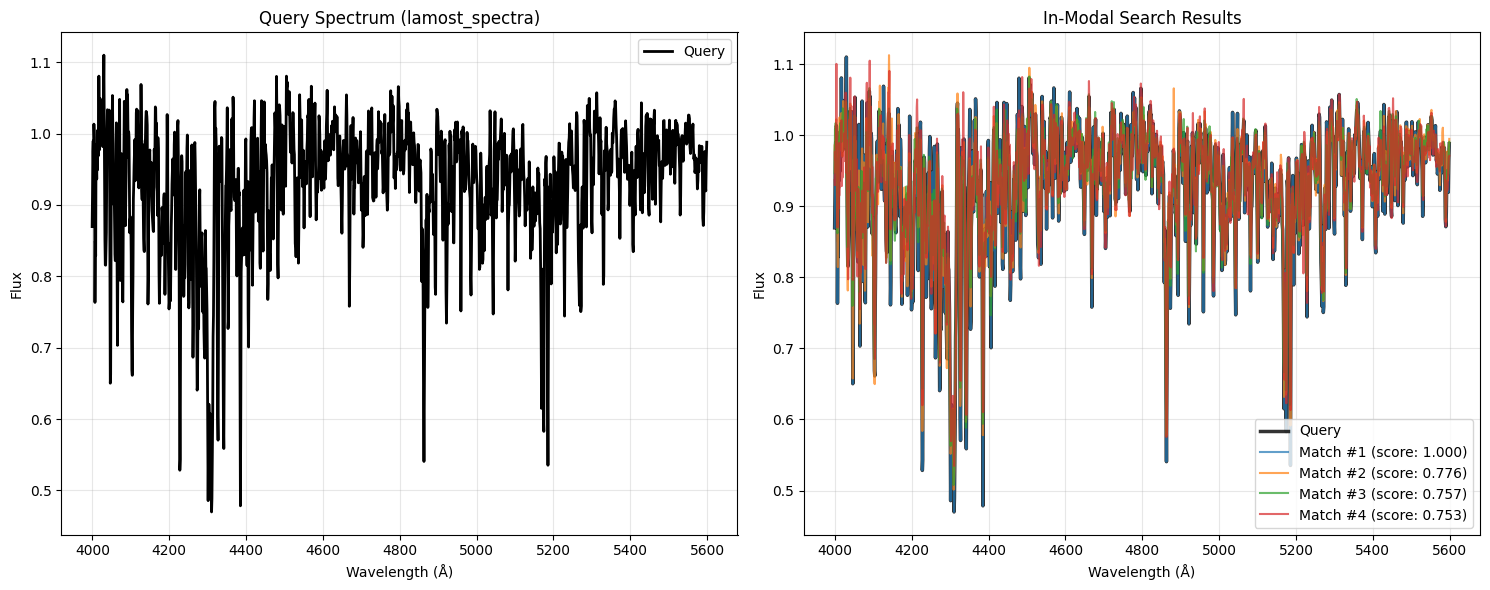

In [22]:
os.makedirs("./plots", exist_ok=True)

query_idx = 100
results_lamost = retriever.find_similar_spectra(
    query_spectrum=query_idx,
    query_type="lamost_spectra",
    search_type="in_modal",
    top_k=4,
    exclude_self=False,
)

print(f"Query index: {query_idx}")
print(f"Top match:   {results_lamost['top_indices'][0]} "
      f"(score {results_lamost['top_scores'][0]:.4f})")
print(f"Query is top match? {results_lamost['top_indices'][0] == query_idx}")

retriever.plot_retrieval_results(
    results_lamost,
    save_path=f"./plots/lamost_in_modal_query_{query_idx}.png",
)


### In-modal retrieval — Gaia XP


Top match: 250 (score 1.0000)


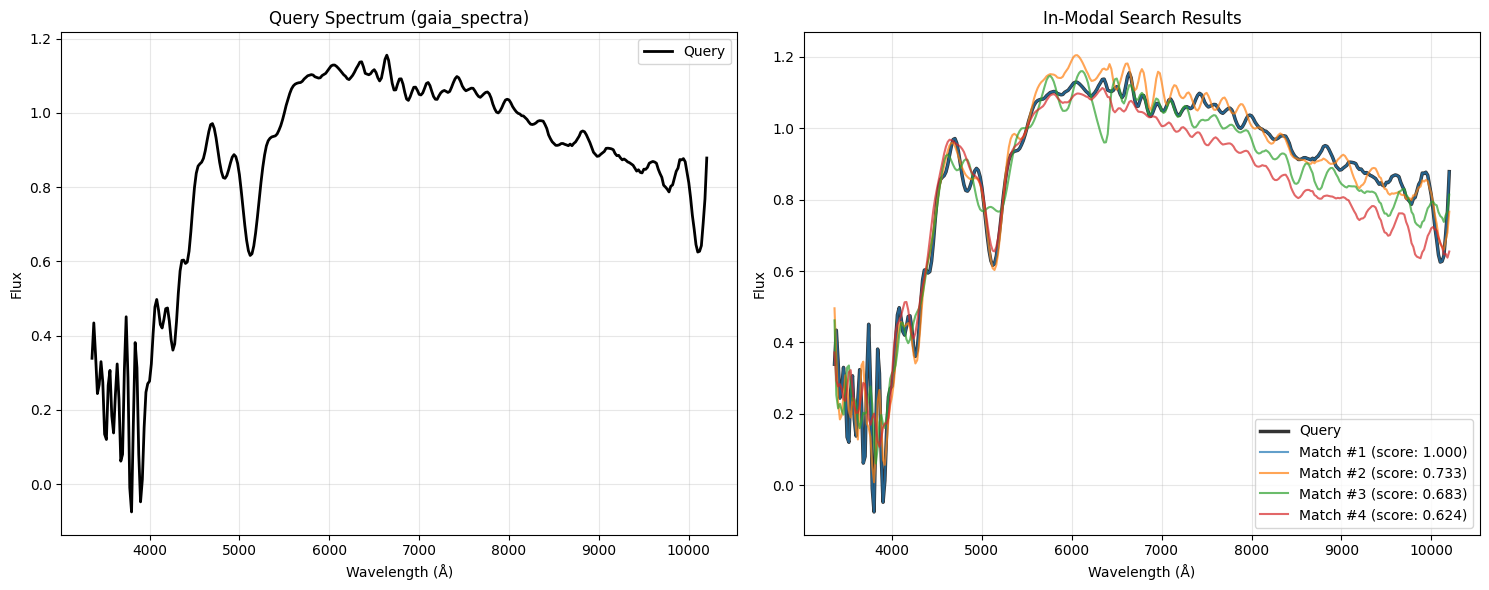

In [23]:
query_idx = 250
results_gaia = retriever.find_similar_spectra(
    query_spectrum=query_idx,
    query_type="gaia_spectra",
    search_type="in_modal",
    top_k=4,
    exclude_self=False,
)
print(f"Top match: {results_gaia['top_indices'][0]} (score {results_gaia['top_scores'][0]:.4f})")
retriever.plot_retrieval_results(results_gaia)


## B2. External-spectrum in-modal retrieval (Task 3)


Top indices: [356 294 412 801]
Top scores:  [0.7553085  0.6835539  0.652397   0.65071285]
  match #1: 665345517107843456
  match #2: 664662857826190976
  match #3: 666015257129054208
  match #4: 2824898401166944768
Saved plot to ./plots/external_lamost_in_modal.png


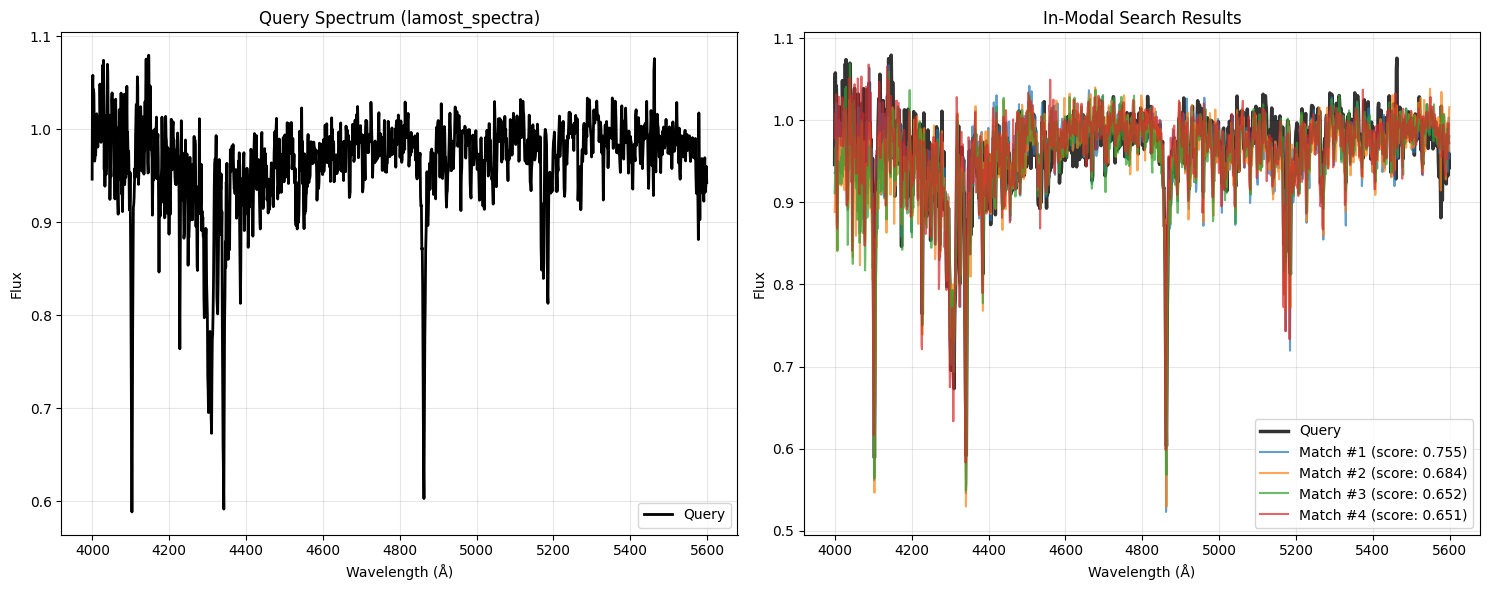

In [24]:
wavelength, flux = load_spectrum_data(
    "./test_data/lrs/spec-55859-F5902_sp02-084.fits.gz"
)

results_ext_lamost = retriever.find_similar_spectra(
    query_spectrum=(wavelength, flux),
    query_type="lamost_spectra",
    search_type="in_modal",
    top_k=4,
)
print("Top indices:", results_ext_lamost["top_indices"])
print("Top scores: ", results_ext_lamost["top_scores"])
for i, sid in enumerate(results_ext_lamost["source_ids"]):
    print(f"  match #{i + 1}: {sid}")

retriever.plot_retrieval_results(
    results_ext_lamost,
    save_path="./plots/external_lamost_in_modal.png",
)


Top scores: [0.50128317 0.43221295 0.41798106 0.41438806]


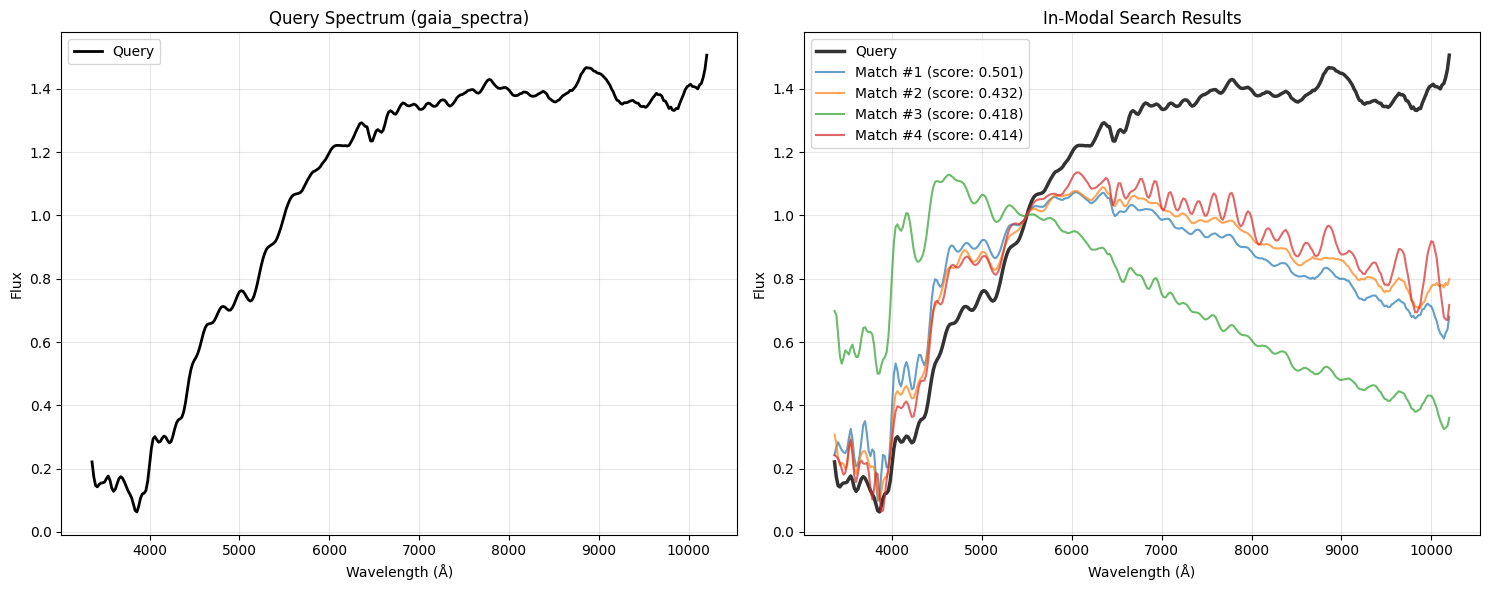

In [25]:
wavelength_xp, flux_xp = load_spectrum_data_xp(
    "./test_data/xp/sample4_txt_xp.csv"
)
results_ext_gaia = retriever.find_similar_spectra(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type="gaia_spectra",
    search_type="in_modal",
    top_k=4,
)
print("Top scores:", results_ext_gaia["top_scores"])
retriever.plot_retrieval_results(results_ext_gaia)


## B3. Cross-modal retrieval (Task 4)


LAMOST query 114 -> Gaia XP top match 114 (score 0.8870)
Paired index recovered? True
Saved plot to ./plots/lamost_to_gaia_cross_modal_query_114.png


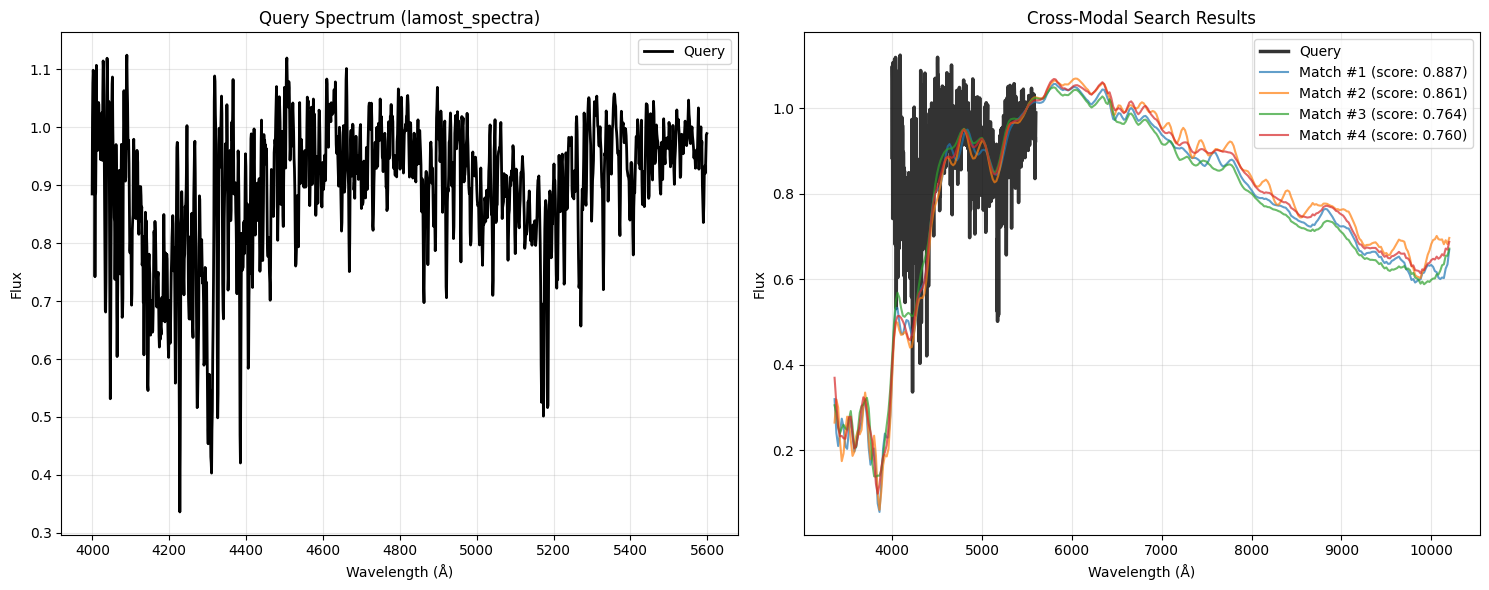

In [26]:
query_idx = 114
results_lamost_to_gaia = retriever.find_similar_spectra(
    query_spectrum=query_idx,
    query_type="lamost_spectra",
    search_type="cross_modal",
    top_k=4,
    exclude_self=False,
)
print(f"LAMOST query {query_idx} -> Gaia XP top match "
      f"{results_lamost_to_gaia['top_indices'][0]} "
      f"(score {results_lamost_to_gaia['top_scores'][0]:.4f})")
print(f"Paired index recovered? "
      f"{results_lamost_to_gaia['top_indices'][0] == query_idx}")

retriever.plot_retrieval_results(
    results_lamost_to_gaia,
    save_path=f"./plots/lamost_to_gaia_cross_modal_query_{query_idx}.png",
)


Gaia query 104 -> LAMOST top match 528
Paired index recovered? False


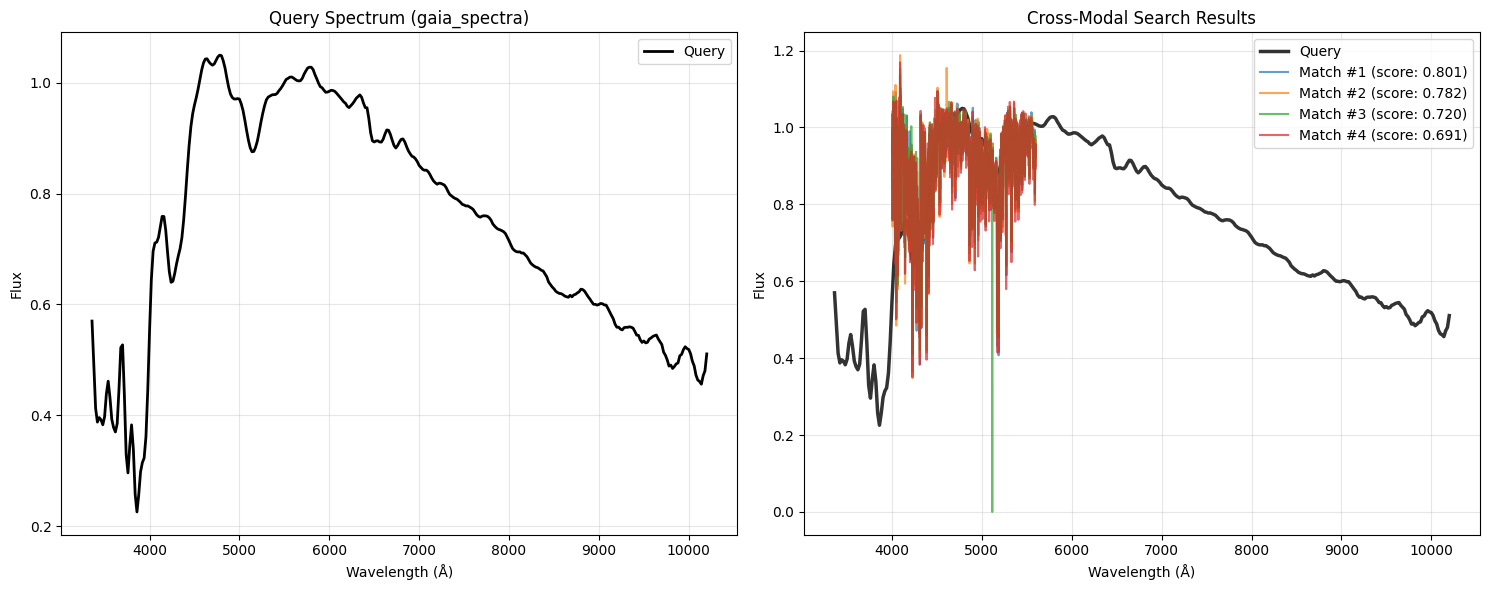

In [27]:
query_idx = 104
results_gaia_to_lamost = retriever.find_similar_spectra(
    query_spectrum=query_idx,
    query_type="gaia_spectra",
    search_type="cross_modal",
    top_k=4,
    exclude_self=False,
)
print(f"Gaia query {query_idx} -> LAMOST top match {results_gaia_to_lamost['top_indices'][0]}")
print(f"Paired index recovered? {results_gaia_to_lamost['top_indices'][0] == query_idx}")
retriever.plot_retrieval_results(results_gaia_to_lamost)


## B4. External cross-modal retrieval (Task 5)


LAMOST -> Gaia XP cross-modal
Top scores: [0.44043666 0.4396359  0.43472916 0.423113  ]
Saved plot to ./plots/external_lamost_to_gaia_cross.png


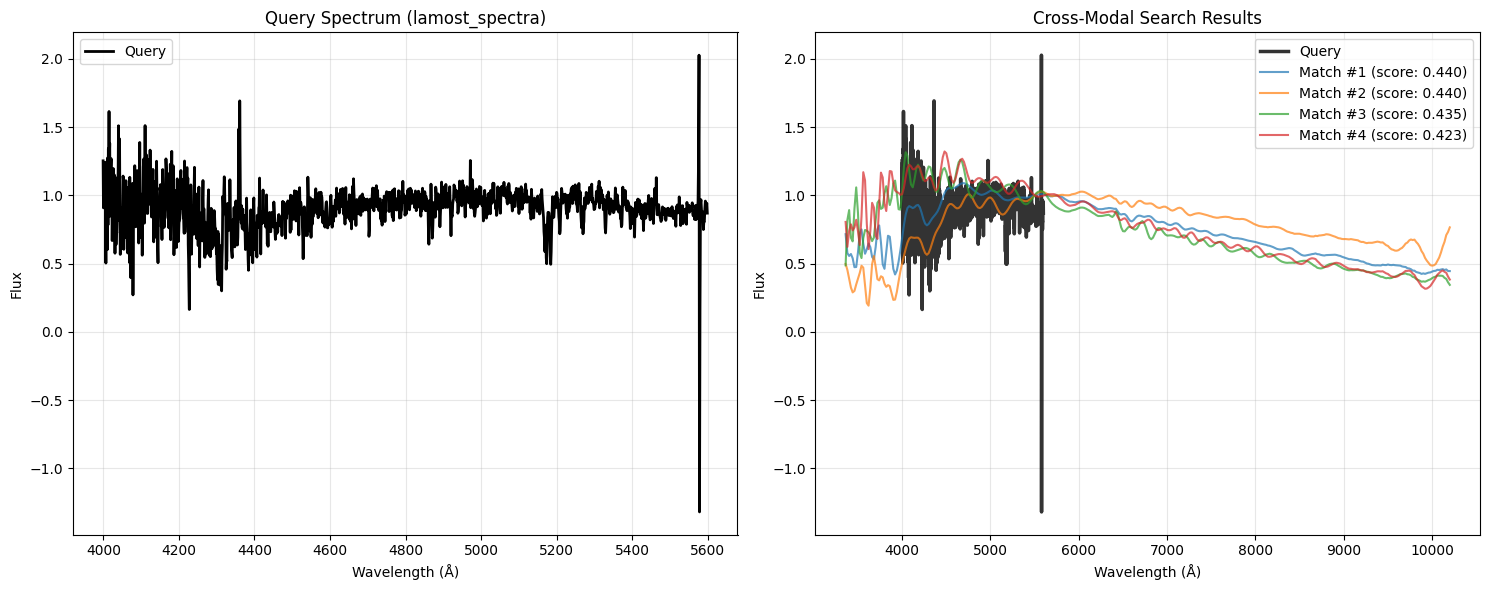

In [28]:
wavelength, flux = load_spectrum_data("./test_data/lrs/sample1_matrix.fits")
results_ext_cross = retriever.find_similar_spectra(
    query_spectrum=(wavelength, flux),
    query_type="lamost_spectra",
    search_type="cross_modal",
    top_k=4,
)
print("LAMOST -> Gaia XP cross-modal")
print("Top scores:", results_ext_cross["top_scores"])
retriever.plot_retrieval_results(
    results_ext_cross,
    save_path="./plots/external_lamost_to_gaia_cross.png",
)


Top score: 0.5993601


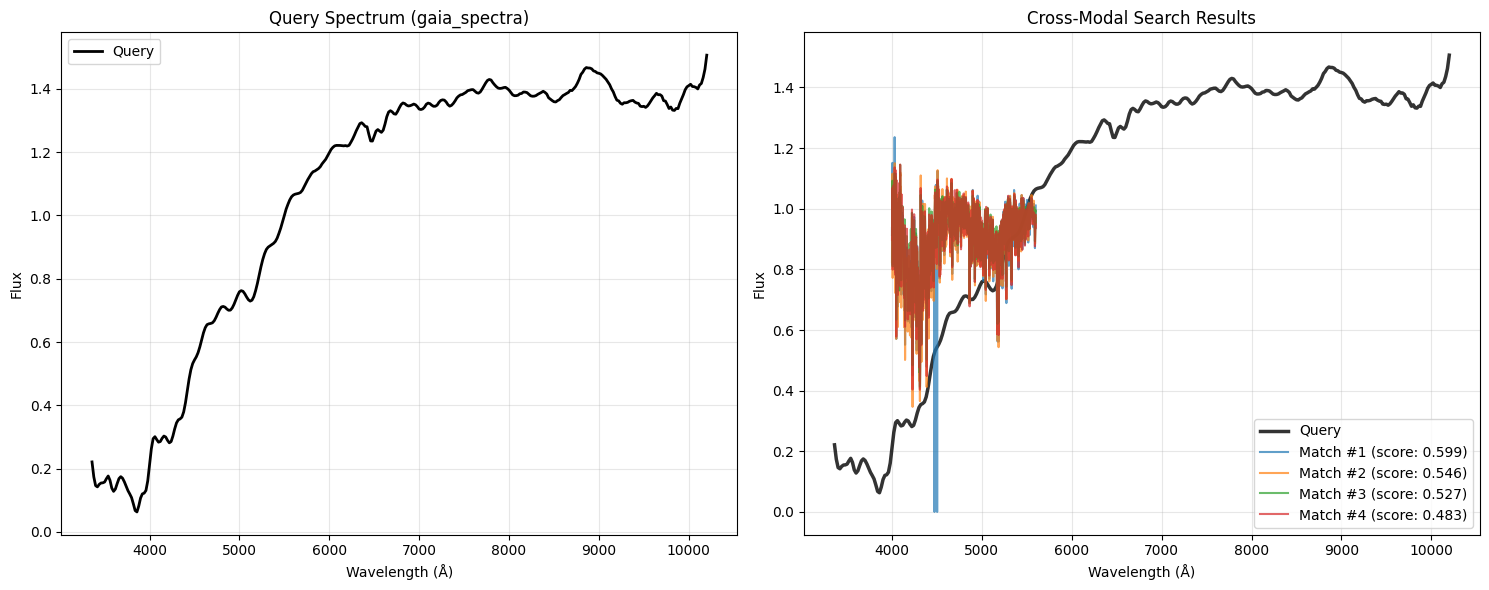

In [29]:
wavelength_xp, flux_xp = load_spectrum_data_xp("./test_data/xp/sample4_txt_xp.csv")
results_ext_gaia_cross = retriever.find_similar_spectra(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type="gaia_spectra",
    search_type="cross_modal",
    top_k=4,
)
print("Top score:", results_ext_gaia_cross["top_scores"][0])
retriever.plot_retrieval_results(results_ext_gaia_cross)


## B5. Cross-modal prediction (Task 6)

Instead of retrieving the closest spectrum from the database, the SpecCLIP decoder generates the corresponding spectrum in the other modality directly.


lamost_spectra -> gaia_spectra
Ground truth available: True
Saved plot to ./plots/lamost_to_gaia_prediction_104.png


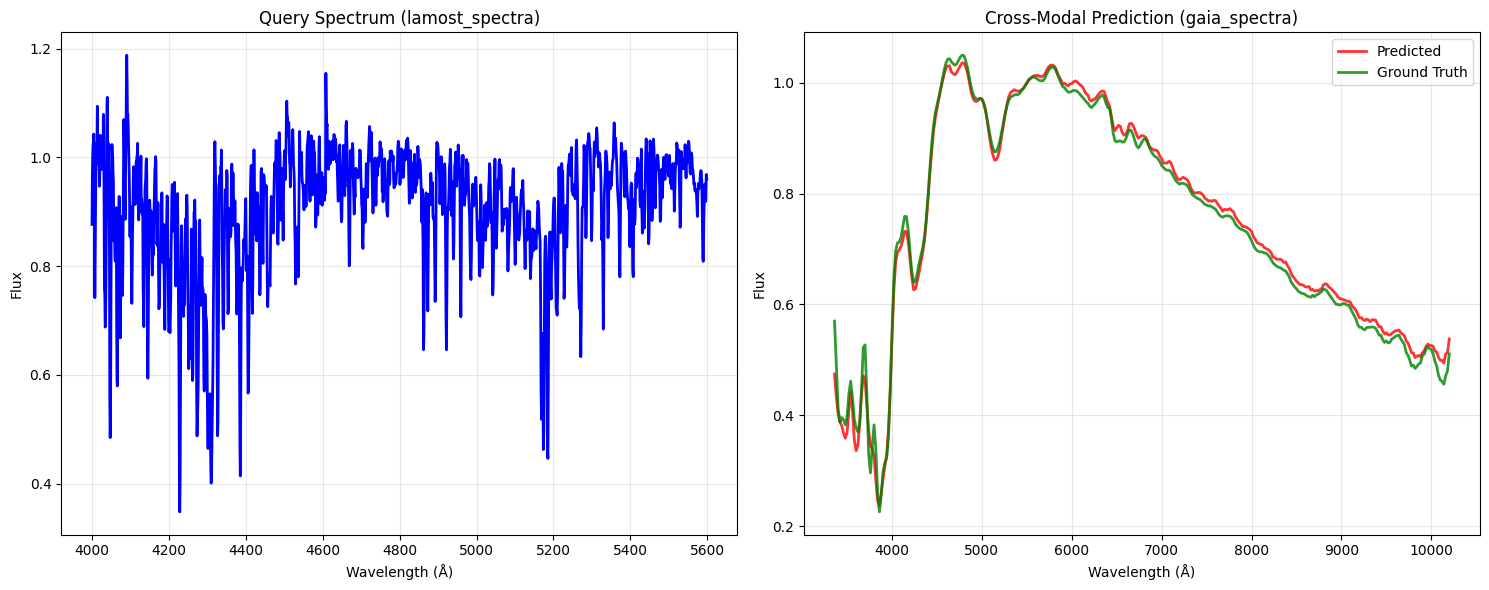

In [30]:
query_idx = 104
prediction = retriever.predict_cross_modal(
    query_spectrum=query_idx,
    query_type="lamost_spectra",
)
print(f"{prediction['query_type']} -> {prediction['predicted_type']}")
print(f"Ground truth available: {prediction['ground_truth'] is not None}")
retriever.plot_cross_modal_prediction(
    prediction,
    save_path=f"./plots/lamost_to_gaia_prediction_{query_idx}.png",
)


Saved plot to ./plots/gaia_to_lamost_prediction_104.png


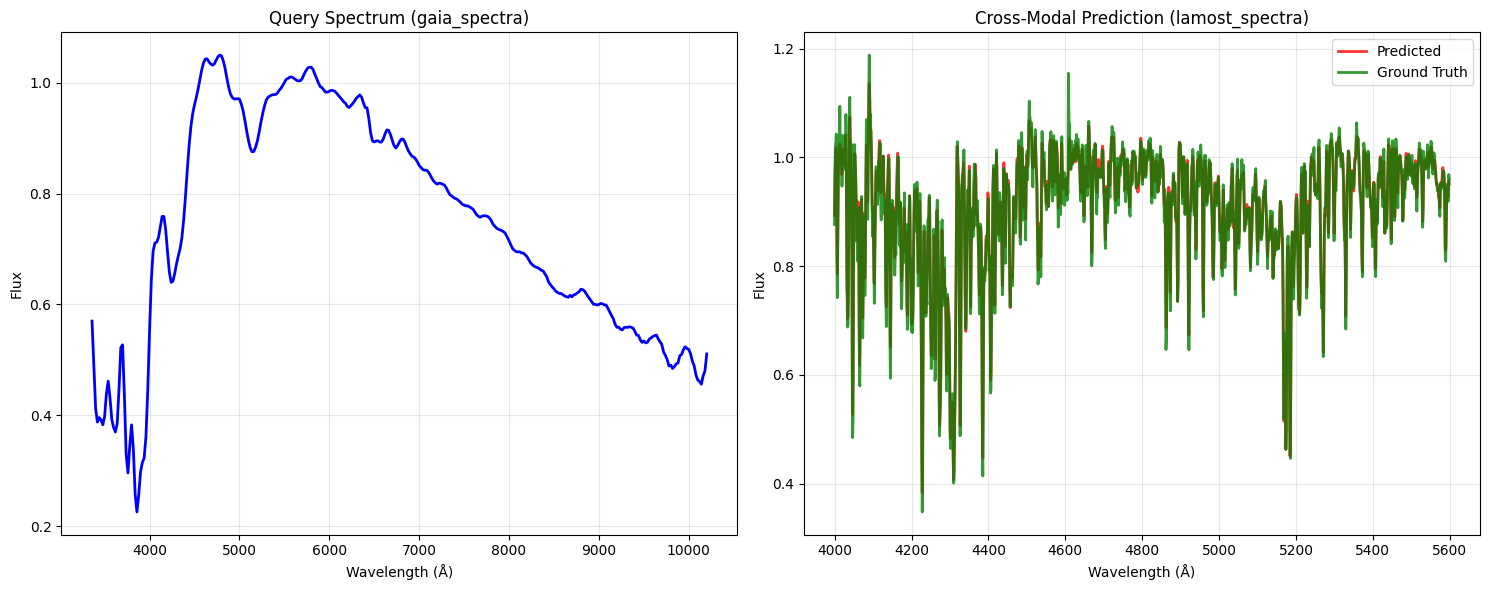

In [31]:
# Predict in the opposite direction
query_idx = 104
prediction = retriever.predict_cross_modal(
    query_spectrum=query_idx,
    query_type="gaia_spectra",
)
retriever.plot_cross_modal_prediction(
    prediction,
    save_path=f"./plots/gaia_to_lamost_prediction_{query_idx}.png",
)


Saved plot to ./plots/external_lamost_to_gaia_prediction.png


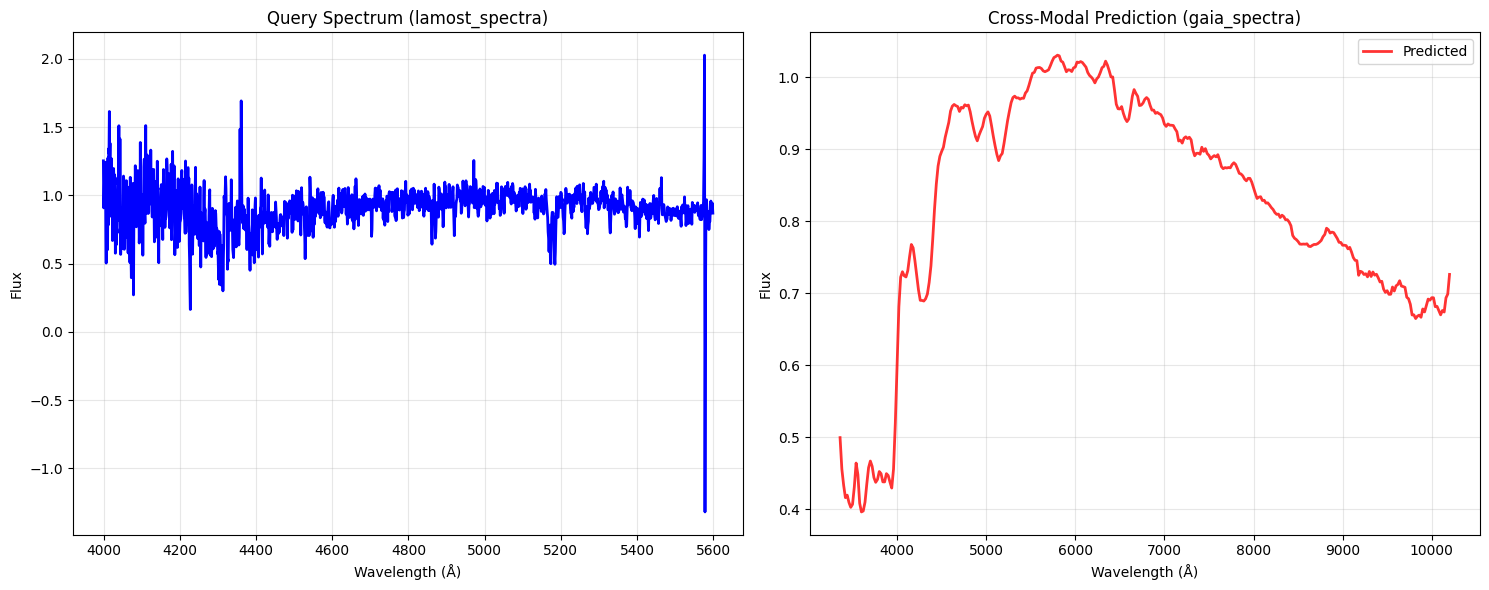

In [32]:
# Cross-modal prediction from an external LAMOST spectrum
wavelength, flux = load_spectrum_data("./test_data/lrs/sample1_matrix.fits")
prediction_ext = retriever.predict_cross_modal(
    query_spectrum=(wavelength, flux),
    query_type="lamost_spectra",
)
retriever.plot_cross_modal_prediction(
    prediction_ext,
    save_path="./plots/external_lamost_to_gaia_prediction.png",
)


Saved plot to ./plots/external_gaia_to_lamost_prediction.png


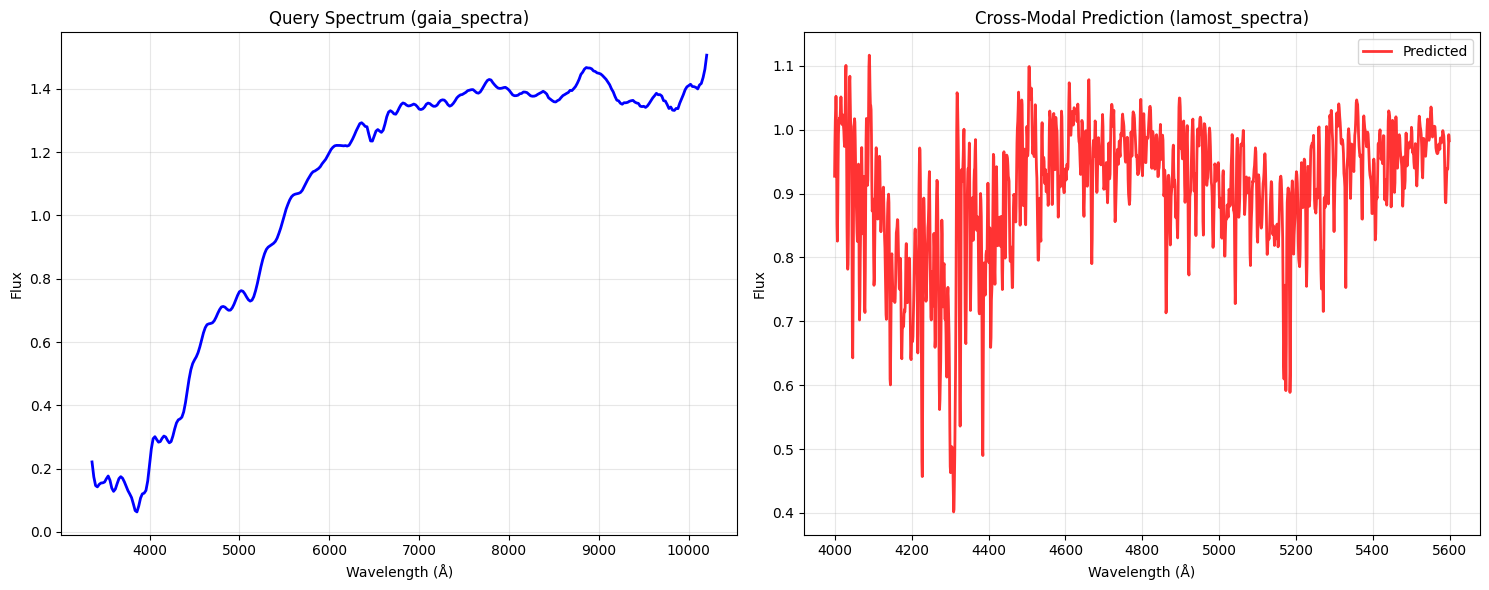

In [33]:
# Cross-modal prediction from an external Gaia XP spectrum
wavelength_xp, flux_xp = load_spectrum_data_xp("./test_data/xp/sample4_txt_xp.csv")
prediction_ext_gaia = retriever.predict_cross_modal(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type="gaia_spectra",
)
retriever.plot_cross_modal_prediction(
    prediction_ext_gaia,
    save_path="./plots/external_gaia_to_lamost_prediction.png",
)


## B6. Batch retrieval over multiple queries


In [34]:
for idx in [10, 50, 100, 250, 500]:
    r = retriever.find_similar_spectra(
        query_spectrum=idx,
        query_type="lamost_spectra",
        search_type="in_modal",
        top_k=4,
        exclude_self=False,
    )
    print(f"  idx {idx}: top match = {r['top_indices'][0]}, "
          f"score = {r['top_scores'][0]:.4f}")


  idx 10: top match = 10, score = 1.0000
  idx 50: top match = 50, score = 1.0000
  idx 100: top match = 100, score = 1.0000
  idx 250: top match = 250, score = 1.0000
  idx 500: top match = 500, score = 1.0000


## B7. Aggregate retrieval statistics over 100 random queries


In-modal:
  Top-1 accuracy: 100%
  Mean score:     1.0000  (std 0.0000)
Cross-modal:
  Top-1 accuracy: 48%
  Mean score:     0.8069  (std 0.0599)


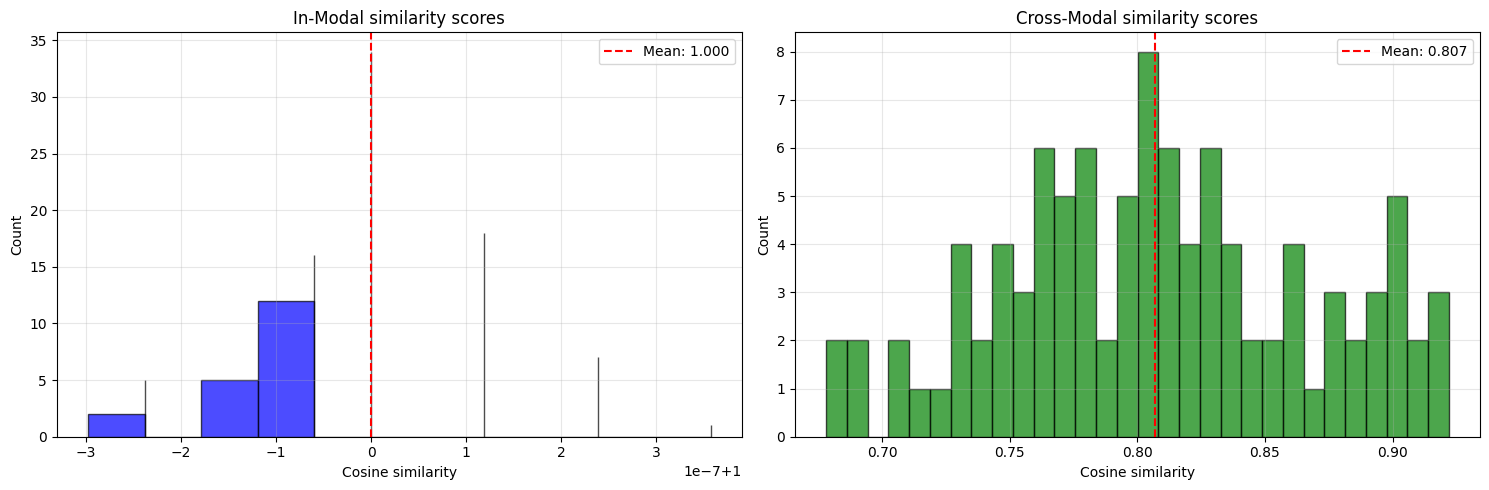

In [35]:
np.random.seed(42)
sample_indices = np.random.choice(len(retriever.source_ids), 100, replace=False)

stats = {
    "in_modal_top1_correct": 0,
    "cross_modal_top1_correct": 0,
    "in_modal_scores": [],
    "cross_modal_scores": [],
}

for idx in sample_indices:
    idx = int(idx)
    in_modal = retriever.find_similar_spectra(
        idx, "lamost_spectra", "in_modal", top_k=1, exclude_self=False,
    )
    if in_modal["top_indices"][0] == idx:
        stats["in_modal_top1_correct"] += 1
    stats["in_modal_scores"].append(in_modal["top_scores"][0])

    cross_modal = retriever.find_similar_spectra(
        idx, "lamost_spectra", "cross_modal", top_k=1,
    )
    if cross_modal["top_indices"][0] == idx:
        stats["cross_modal_top1_correct"] += 1
    stats["cross_modal_scores"].append(cross_modal["top_scores"][0])

print(f"In-modal:")
print(f"  Top-1 accuracy: {stats['in_modal_top1_correct']}%")
print(f"  Mean score:     {np.mean(stats['in_modal_scores']):.4f}  "
      f"(std {np.std(stats['in_modal_scores']):.4f})")
print(f"Cross-modal:")
print(f"  Top-1 accuracy: {stats['cross_modal_top1_correct']}%")
print(f"  Mean score:     {np.mean(stats['cross_modal_scores']):.4f}  "
      f"(std {np.std(stats['cross_modal_scores']):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(stats["in_modal_scores"], bins=30, alpha=0.7, color="blue", edgecolor="black")
axes[0].set(title="In-Modal similarity scores", xlabel="Cosine similarity", ylabel="Count")
axes[0].axvline(np.mean(stats["in_modal_scores"]), color="red", linestyle="--",
                label=f"Mean: {np.mean(stats['in_modal_scores']):.3f}")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(stats["cross_modal_scores"], bins=30, alpha=0.7, color="green", edgecolor="black")
axes[1].set(title="Cross-Modal similarity scores", xlabel="Cosine similarity", ylabel="Count")
axes[1].axvline(np.mean(stats["cross_modal_scores"]), color="red", linestyle="--",
                label=f"Mean: {np.mean(stats['cross_modal_scores']):.3f}")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./plots/score_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


---

# Part C — Comprehensive Analysis Cards

`retriever.generate_analysis_card(...)` combines all the pieces into a single multi-panel figure for one query spectrum:

1. **Stellar parameter estimation** — every parameter the relevant predictor produces
2. **In-modal retrieval** — top-1 neighbour in the same survey, with similarity score
3. **Cross-modal retrieval** — top-1 neighbour in the other survey
4. **Cross-modal prediction** — the model's generated paired spectrum

Together these are useful as a diagnostic when you want a single "what does SpecCLIP think about this star?" sheet.


## C1. Analysis card for a LAMOST test-sample spectrum (possibly a young star)


Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/lrs_encoder.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/lrs_encoder.ckpt`


Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`


Total trainable parameters: 42,846,129


...

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  - Finding in-modal match...
  - Finding cross-modal match...
  - Generating cross-modal prediction...
  - Creating visualization...
✓ Saved analysis card to ./cards/lamost_test_sample_analysis_card.png


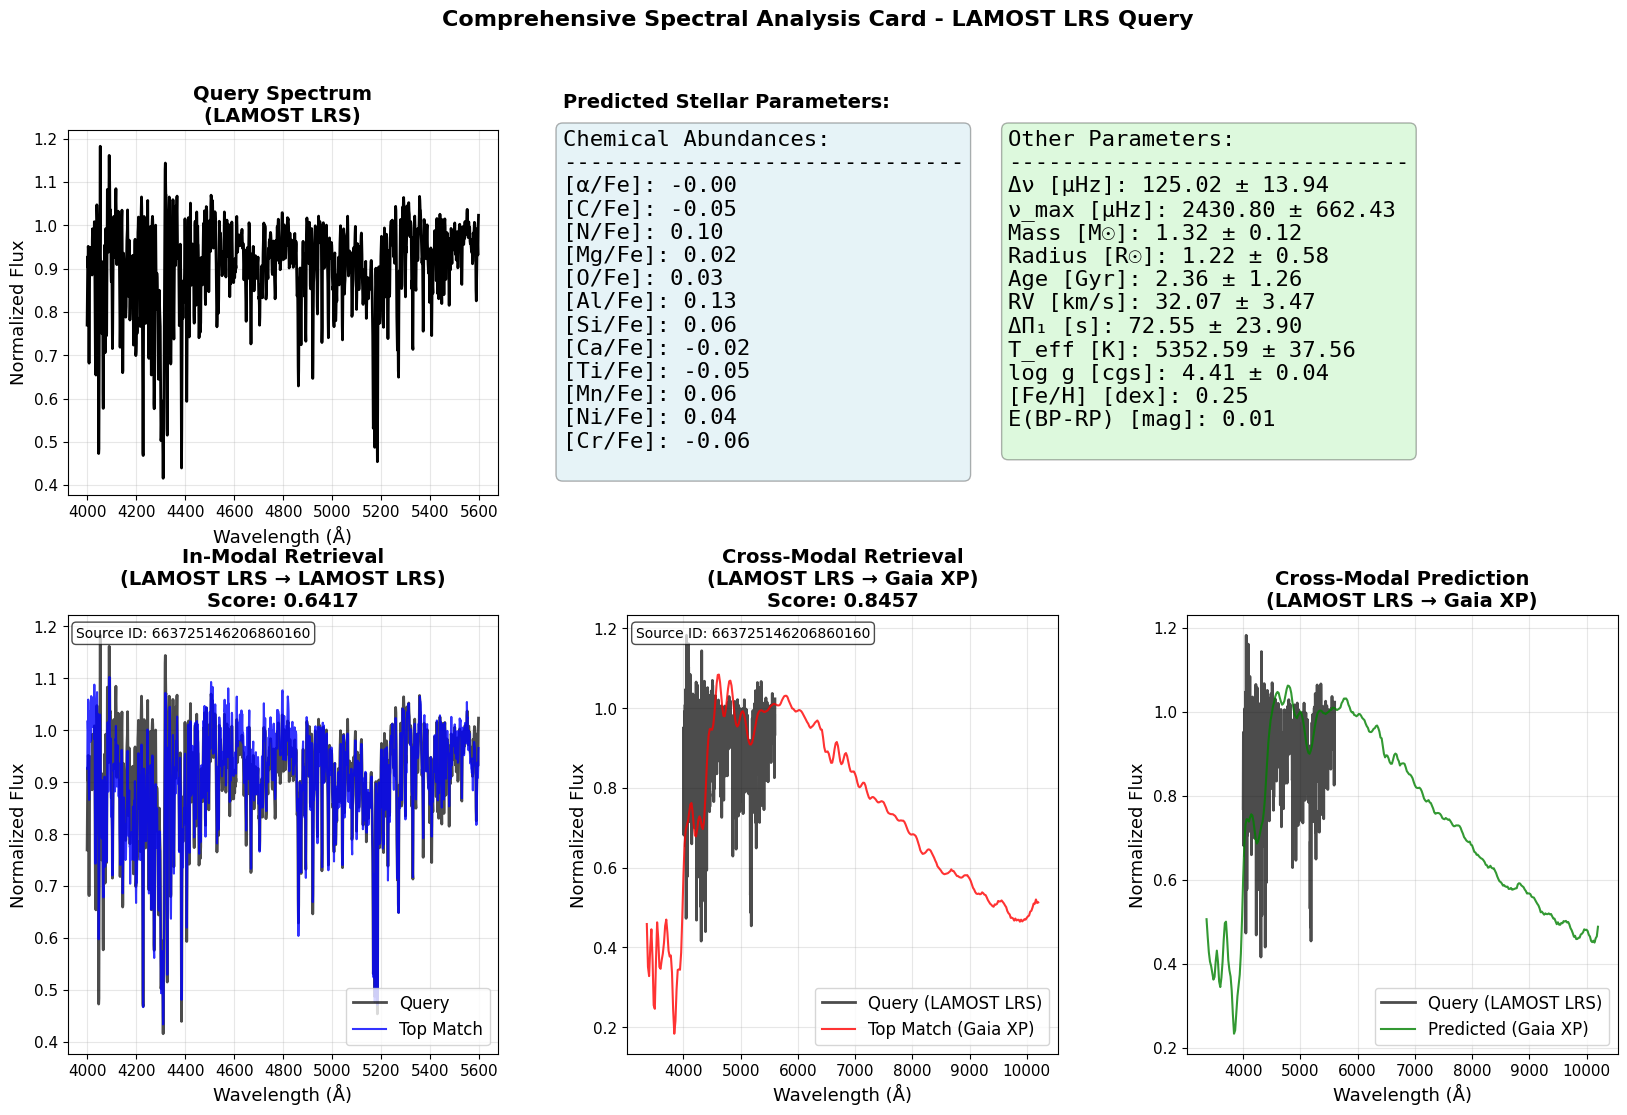

✓ Analysis card generation complete!

Stellar parameters:


,Parameter,Prediction,Error,Method
0,[α/Fe],-0.00,NaN,MLP
1,[C/Fe],-0.05,NaN,MLP
2,[N/Fe],0.10,NaN,MLP
3,[Mg/Fe],0.02,NaN,MLP
4,[O/Fe],0.03,NaN,MLP
5,[Al/Fe],0.13,NaN,MLP
6,[Si/Fe],0.06,NaN,MLP
7,[Ca/Fe],-0.02,NaN,MLP
8,[Ti/Fe],-0.05,NaN,MLP
9,[Mn/Fe],0.06,NaN,MLP



In-modal score:    0.6417
Cross-modal score: 0.8457


In [36]:
os.makedirs("./cards", exist_ok=True)

with h5py.File(h5_data_path, "r") as f:
    lamost_spectra_card = np.array(f["test/lamost_spectra"][:])

w_start = 3.602
w_end = w_start + 1e-4 * 1461
new_log_wave = np.linspace(w_start, w_end, 1462)
wavelength = 10 ** new_log_wave
flux = lamost_spectra_card[86][..., 0]

stellar_predictor = UnifiedStellarParameterPredictor("LAMOST_LRS", lrs_config=lrs_config)

card_results = retriever.generate_analysis_card(
    query_spectrum=(wavelength, flux),
    query_type="lamost_spectra",
    stellar_predictor=stellar_predictor,
    save_path="./cards/lamost_test_sample_analysis_card.png",
    simple_header=False,
)
print("\nStellar parameters:")
display(card_results["stellar_parameters"])
print(f"\nIn-modal score:    {card_results['in_modal_match']['score']:.4f}")
print(f"Cross-modal score: {card_results['cross_modal_match']['score']:.4f}")


## C2. Analysis card for an external LAMOST spectrum (possibly an old star)


Initializing LAMOST LRS predictor...
This predictor supports:
  - Chemical abundances (12 elements)
  - Asteroseismic parameters
  - Radial velocity
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/lrs_encoder.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/lrs_encoder.ckpt`


Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`


Total trainable parameters: 42,846,129


...

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  - Finding in-modal match...
  - Finding cross-modal match...
  - Generating cross-modal prediction...
  - Creating visualization...
✓ Saved analysis card to ./cards/lamost_external_analysis_card.png


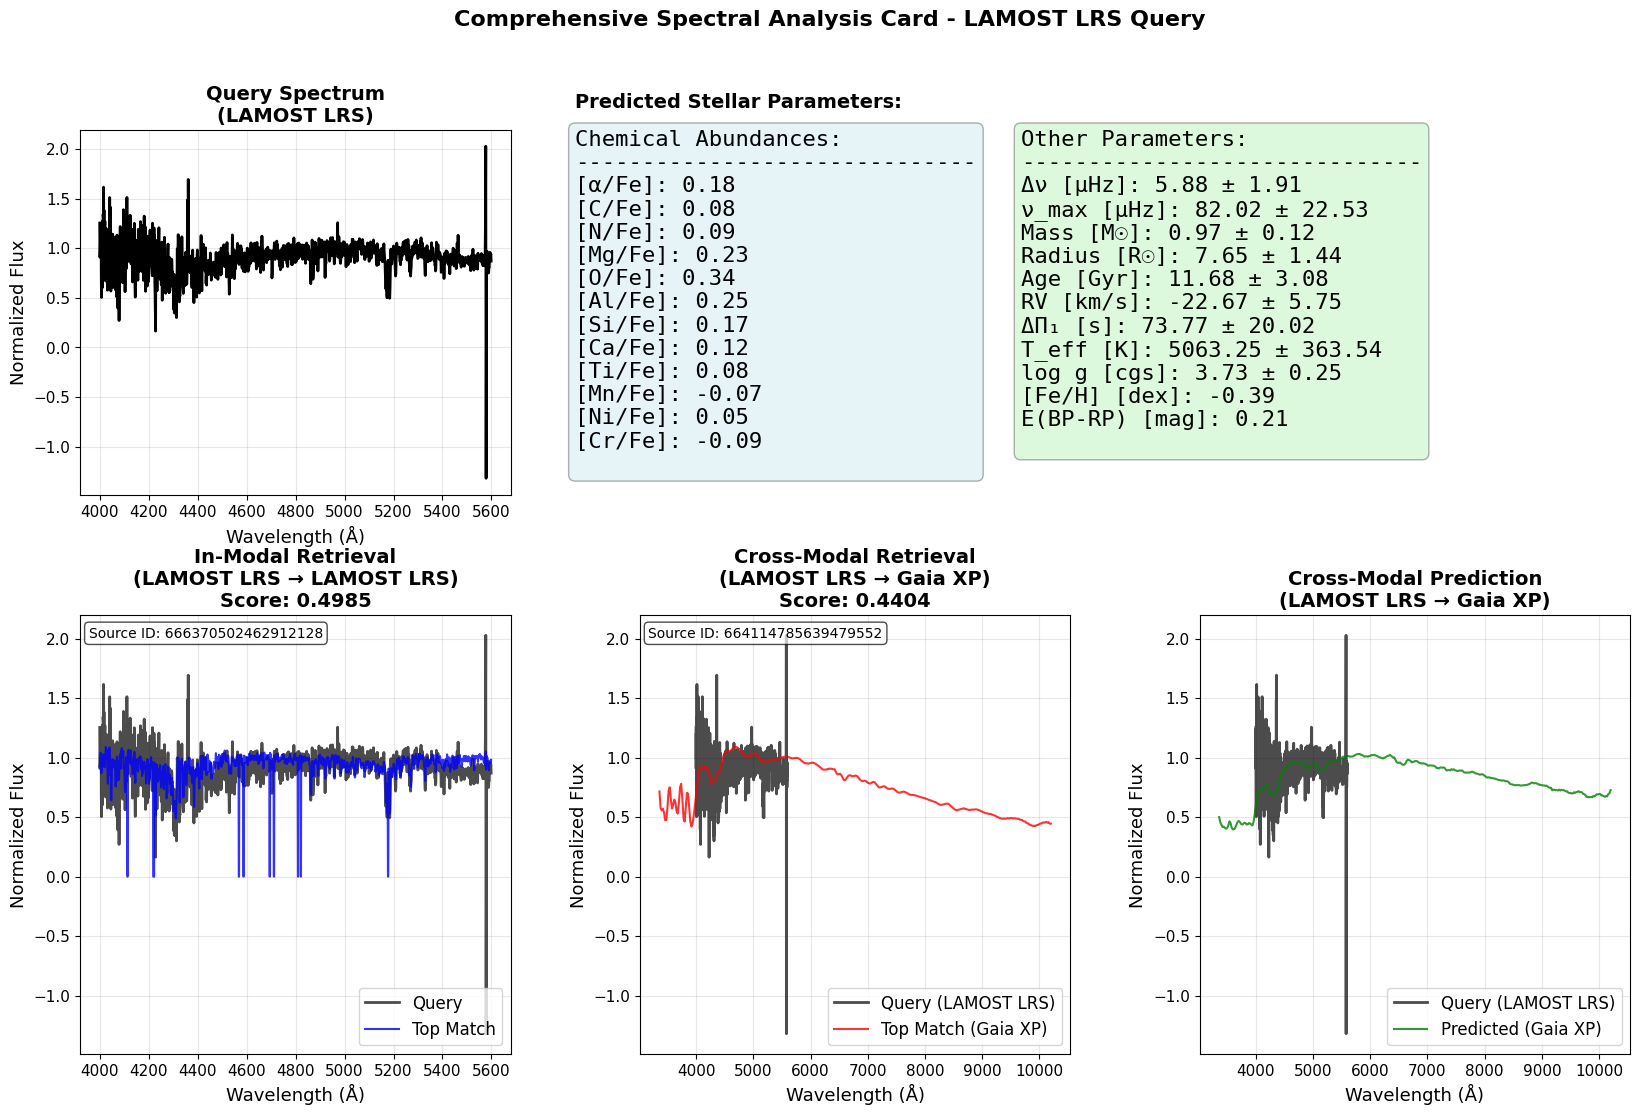

✓ Analysis card generation complete!

Stellar parameters:


,Parameter,Prediction,Error,Method
0,[α/Fe],0.18,NaN,MLP
1,[C/Fe],0.08,NaN,MLP
2,[N/Fe],0.09,NaN,MLP
3,[Mg/Fe],0.23,NaN,MLP
4,[O/Fe],0.34,NaN,MLP
5,[Al/Fe],0.25,NaN,MLP
6,[Si/Fe],0.17,NaN,MLP
7,[Ca/Fe],0.12,NaN,MLP
8,[Ti/Fe],0.08,NaN,MLP
9,[Mn/Fe],-0.07,NaN,MLP



In-modal score:    0.4985
Cross-modal score: 0.4404


In [37]:
stellar_predictor = UnifiedStellarParameterPredictor("LAMOST_LRS", lrs_config=lrs_config)

wavelength, flux = load_spectrum_data("./test_data/lrs/sample1_matrix.fits")
# Other interesting test files you can try:
#   ./test_data/lrs/sample4_txt.csv
#   ./test_data/lrs/spec-55859-F5902_sp04-056.fits.gz
#   ./test_data/lrs/spec-57101-HD152912N162344B01_sp01-026.fits.gz

card_results = retriever.generate_analysis_card(
    query_spectrum=(wavelength, flux),
    query_type="lamost_spectra",
    stellar_predictor=stellar_predictor,
    save_path="./cards/lamost_external_analysis_card.png",
    simple_header=False,
)
print("\nStellar parameters:")
display(card_results["stellar_parameters"])
print(f"\nIn-modal score:    {card_results['in_modal_match']['score']:.4f}")
print(f"Cross-modal score: {card_results['cross_modal_match']['score']:.4f}")


## C3. Analysis card for a Gaia XP test-sample spectrum


Initializing Gaia XP predictor...
This predictor supports:
  - Alpha element abundance
  - Carbon and Nitrogen abundances
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/xp_encoder_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/xp_encoder_mlp.ckpt`


Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`


Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_split_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_split_mlp.ckpt`


Models loaded successfully!
Generating comprehensive analysis card...
  - Predicting stellar parameters...


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  - Finding in-modal match...
  - Finding cross-modal match...
  - Generating cross-modal prediction...
  - Creating visualization...
✓ Saved analysis card to ./cards/gaia_xp_test_sample_analysis_card.png


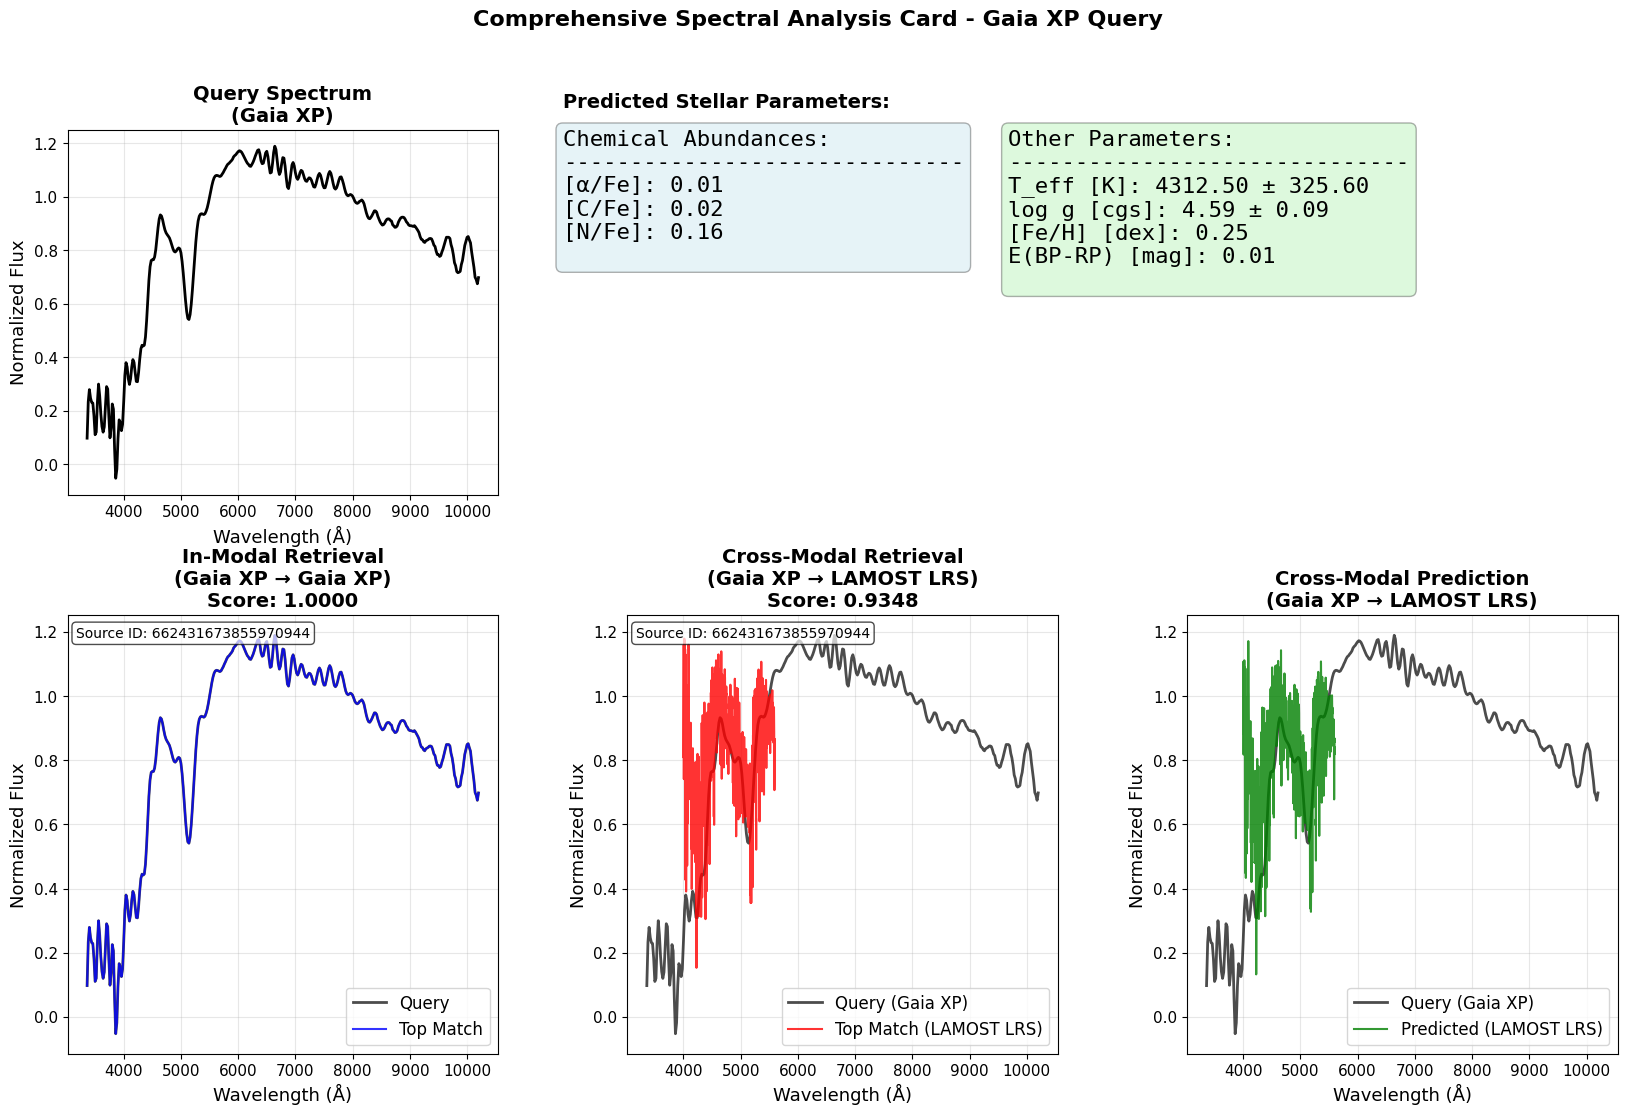

✓ Analysis card generation complete!


In [38]:
with h5py.File(h5_data_path, "r") as f:
    gaia_spectra_card = np.array(f["test/gaia_spectra"][:])

stellar_predictor_xp = UnifiedStellarParameterPredictor("Gaia_XP", xp_config=xp_config)

wavelength_xp = np.arange(336, 1021, 2)
flux_xp = gaia_spectra_card[72][..., 0]

card_results_xp = retriever.generate_analysis_card(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type="gaia_spectra",
    stellar_predictor=stellar_predictor_xp,
    save_path="./cards/gaia_xp_test_sample_analysis_card.png",
    simple_header=False,
)


## C4. Analysis card for an external Gaia XP spectrum


Initializing Gaia XP predictor...
This predictor supports:
  - Alpha element abundance
  - Carbon and Nitrogen abundances
  - Atmospheric parameters
  - Reddening
Using device: cuda
Loading models...


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/xp_encoder_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/encoders/xp_encoder_mlp.ckpt`


Total trainable parameters: 42,846,129
Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_predrecon_mlp.ckpt`


Total trainable parameters: 42,846,129


INFO: Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_split_mlp.ckpt`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.9.1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint pretrained_models/specclip/specclip_model_split_mlp.ckpt`


Models loaded successfully!
Generating comprehensive analysis card...
  - Predicting stellar parameters...


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

  - Finding in-modal match...
  - Finding cross-modal match...
  - Generating cross-modal prediction...
  - Creating visualization...
✓ Saved analysis card to ./cards/gaia_xp_external_analysis_card.png


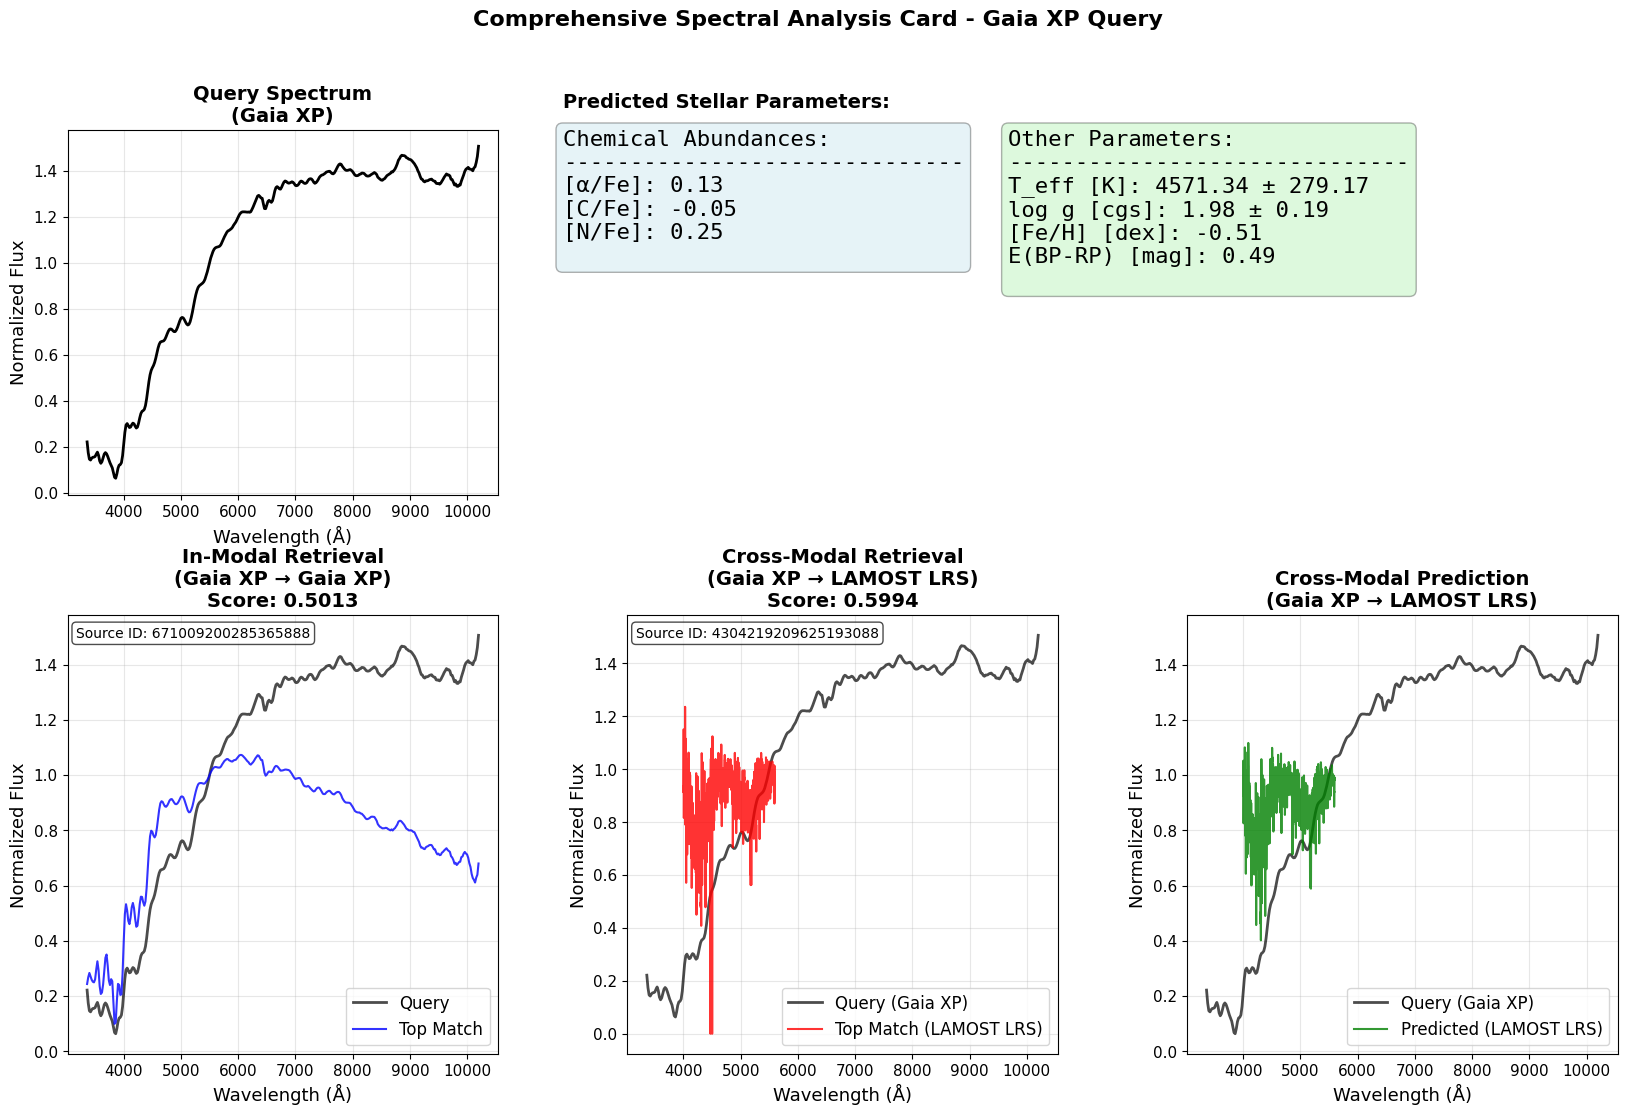

✓ Analysis card generation complete!


In [39]:
stellar_predictor_xp = UnifiedStellarParameterPredictor("Gaia_XP", xp_config=xp_config)

wavelength_xp, flux_xp = load_spectrum_data_xp("./test_data/xp/sample4_txt_xp.csv")

card_results_xp = retriever.generate_analysis_card(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type="gaia_spectra",
    stellar_predictor=stellar_predictor_xp,
    save_path="./cards/gaia_xp_external_analysis_card.png",
    simple_header=False,
)


---

## Summary

You ran a full SpecCLIP pipeline end-to-end:

- Cloned the repo and installed the slim runtime requirements
- Authenticated with Hugging Face and downloaded ~2.3 GB of pretrained checkpoints + a paired test set
- **Predicted stellar parameters** for both LAMOST LRS and Gaia XP spectra (atmospheric, chemical, asteroseismic, extinction)
- Compared LAMOST vs Gaia XP predictions for the same star
- Built a shared-space embedding database and performed **in-modal** and **cross-modal** retrieval (test-set + external spectra)
- Generated the **paired spectrum** in the other survey via cross-modal prediction
- Produced **analysis cards** combining all of the above for individual stars

### Where to go next

- **Try your own spectra.** Replace the file paths in the "External …" cells with your FITS / CSV files. Use `predict_lrs_wclip_v0.load_spectrum_data` for LAMOST LRS-style spectra and `predict_xp_wclip_v0.load_spectrum_data` for Gaia XP-style spectra.
- **Read the paper.** [arXiv:2507.01939](https://arxiv.org/abs/2507.01939) for architecture, training data, and ablations.
- **Issues and feature requests** on the [GitHub repo](https://github.com/Xiaosheng-Zhao/SpecCLIP).
